<img src="assets/bricks.jpg">

# Import Statements

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


# Data Exploration

**Challenge**: How many different colours does the LEGO company produce? Read the colors.csv file in the data folder and find the total number of unique colours.

In [18]:
colors = pd.read_csv("data/colors.csv")
colors.head()

,id,name,rgb,is_trans
0,-1,Unknown,0033B2,f
1,0,Black,05131D,f
2,1,Blue,0055BF,f
3,2,Green,237841,f
4,3,Dark Turquoise,008F9B,f


In [19]:
colors['name'].nunique()

135

**Challenge**: Find the number of transparent colours where <code>is_trans == 't'</code> versus the number of opaque colours where <code>is_trans == 'f'</code>.

In [20]:
colors.groupby('is_trans').count()

,id,name,rgb
is_trans,,,
f,107,107,107
t,28,28,28


# Understanding LEGO Themes vs. LEGO Sets

Walk into a LEGO store and you will see their products organised by theme. Their themes include Star Wars, Batman, Harry Potter and many more.

<img src="assets/lego_themes.png">

A lego **set** is a particular box of LEGO or product. Therefore, a single theme typically has many different sets.

<img src="assets/lego_sets.png">

The <code>sets.csv</code> data contains a list of sets over the years and the number of parts that each of these sets contained.

**Challenge**: Read the sets.csv data and take a look at the first and last couple of rows. 

In [21]:
sets = pd.read_csv("data/sets.csv")
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [22]:
sets.tail()

,set_num,name,year,theme_id,num_parts
15705,wwgp1-1,Wild West Limited Edition Gift Pack,1996,476,0
15706,XMASTREE-1,Christmas Tree,2019,410,26
15707,XWING-1,Mini X-Wing Fighter,2019,158,60
15708,XWING-2,X-Wing Trench Run,2019,158,52
15709,YODACHRON-1,Yoda Chronicles Promotional Set,2013,158,413


**Challenge**: In which year were the first LEGO sets released and what were these sets called?

In [33]:
sets.sort_values('year') # sort by year
first_year = sets["year"].min() # get the first year
first_year_sets = sets[sets["year"] == first_year] # get the sets from that year
set_names = first_year_sets["name"].tolist() # get the names of the sets

print(f"The first LEGO sets in the dataset were released in {first_year}.")
print("These sets were called:")
for name in set_names:
    print("-", name)

The first LEGO sets in the dataset were released in 1949.
These sets were called:
- Extra-Large Gift Set (ABB)
- Large Gift Set (ABB)
- Medium Gift Set (ABB)
- Small Brick Set (ABB)
- Small Doors and Windows Set (ABB)


**Challenge**: How many different sets did LEGO sell in their first year? How many types of LEGO products were on offer in the year the company started?

In [35]:
num_sets = first_year_sets.shape[0] # how many different sets sell in their first year
num_themes = first_year_sets["theme_id"].nunique() # how many themes exist in their first year

print(f"In {first_year}, LEGO sold {num_sets} different sets.")
print(f"In that same year, LEGO offered {num_themes} types of LEGO products (themes).")

In 1949, LEGO sold 5 different sets.
In that same year, LEGO offered 2 types of LEGO products (themes).


**Challenge**: Find the top 5 LEGO sets with the most number of parts. 

In [36]:
top5_parts = sets.sort_values("num_parts", ascending=False).head(5) # top 5 sets with the most number of parts
top5_parts[["set_num", "name", "num_parts"]]

,set_num,name,num_parts
15004,BIGBOX-1,The Ultimate Battle for Chima,9987
11183,75192-1,UCS Millennium Falcon,7541
10551,71043-1,Hogwarts Castle,6020
295,10256-1,Taj Mahal,5923
221,10189-1,Taj Mahal,5922


**Challenge**: Use <code>.groupby()</code> and <code>.count()</code> to show the number of LEGO sets released year-on-year. How do the number of sets released in 1955 compare to the number of sets released in 2019? 

In [38]:
sets_per_year = sets.groupby("year")["set_num"].count() # number of sets released per year
sets_per_year

year
1949      5
1950      6
1953      4
1954     14
1955     28
       ... 
2017    786
2018    816
2019    840
2020    674
2021      3
Name: set_num, Length: 71, dtype: int64

In [39]:
sets_1955 = sets_per_year.loc[1955] # get the number of sets released in 1955
sets_2019 = sets_per_year.loc[2019] # get the number of sets released in 2019

print(f"LEGO released {sets_1955} sets in 1955.")
print(f"LEGO released {sets_2019} sets in 2019.")

LEGO released 28 sets in 1955.
LEGO released 840 sets in 2019.


**Challenge**: Show the number of LEGO releases on a line chart using Matplotlib. <br>
<br>
Note that the .csv file is from late 2020, so to plot the full calendar years, you will have to exclude some data from your chart. Can you use the slicing techniques covered in Day 21 to avoid plotting the last two years? The same syntax will work on Pandas DataFrames. 

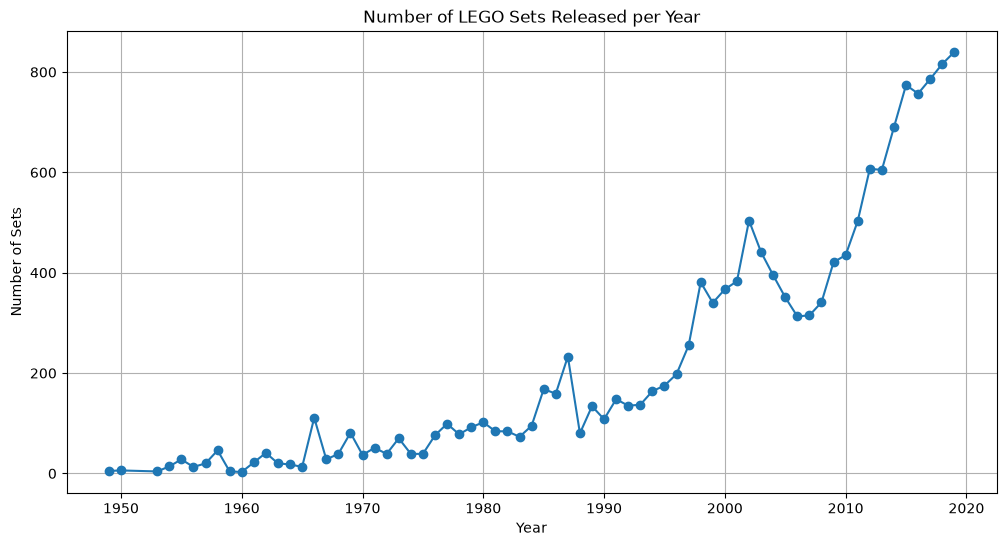

In [45]:
sets_per_year_clean = sets_per_year[:-2] # remove last 2 indexes

plt.figure(figsize=(12,6))
plt.plot(sets_per_year_clean.index, sets_per_year_clean.values, marker='o')
plt.title("Number of LEGO Sets Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Sets")
plt.grid(True)
plt.show()

### Aggregate Data with the Python .agg() Function

Let's work out the number of different themes shipped by year. This means we have to count the number of unique theme_ids per calendar year.

**Challenge**: Plot the number of themes released by year on a line chart. Only include the full calendar years (i.e., exclude 2020 and 2021). 

### Line Charts with Two Seperate Axes

**Challenge**: Use the <code>.groupby()</code> and <code>.agg()</code> function together to figure out the average number of parts per set. How many parts did the average LEGO set released in 1954 compared to say, 2017?

### Scatter Plots in Matplotlib

**Challenge**: Has the size and complexity of LEGO sets increased over time based on the number of parts? Plot the average number of parts over time using a Matplotlib scatter plot. See if you can use the [scatter plot documentation](https://matplotlib.org/3.1.0/api/_as_gen/matplotlib.pyplot.scatter.html) before I show you the solution. Do you spot a trend in the chart? 

### Number of Sets per LEGO Theme

LEGO has licensed many hit franchises from Harry Potter to Marvel Super Heros to many others. But which theme has the largest number of individual sets? 

**Challenge** Use what you know about HTML markup and tags to display the database schema: https://i.imgur.com/Sg4lcjx.png

### Database Schemas, Foreign Keys and Merging DataFrames

The themes.csv file has the actual theme names. The sets .csv has <code>theme_ids</code> which link to the <code>id</code> column in the themes.csv. 

**Challenge**: Explore the themes.csv. How is it structured? Search for the name 'Star Wars'. How many <code>id</code>s correspond to this name in the themes.csv? Now use these <code>id</code>s and find the corresponding the sets in the sets.csv (Hint: you'll need to look for matches in the <code>theme_id</code> column)

### Merging (i.e., Combining) DataFrames based on a Key
